170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Target values (example): [[6]
 [9]
 [9]
 [4]
 [1]]
Training data shape: (37500, 32, 32, 3), Validation data shape: (12500, 32, 32, 3), Test data shape: (10000, 32, 32, 3)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.2510 - loss: 1.9967 - val_accuracy: 0.4367 - val_loss: 1.5467
Epoch 2/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3788 - loss: 1.6404 - val_accuracy: 0.5028 - val_loss: 1.4019
Epoch 3/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.4041 - loss: 1.5521 - val_accuracy: 0.5356 - val_loss: 1.3149
Epoch 4/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4195 - loss: 1.5059 - val_accuracy: 0.5422 - val_loss: 1.3162
Epoch 5/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4346 - loss: 1.4670 - val_accuracy: 0.5616 - val_loss: 1.2523
Epoch 6/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4406 - loss: 1.4447 - val_accuracy: 0.5762 - val_loss: 1.2313
Epoch 7/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4562 - loss: 1.4162 - val_accuracy: 0.5726 - val_loss: 1.2384
Epoch 8/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4576 - loss: 1.4130 - val_accuracy: 

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/up_sampling2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 269s 415ms/step - accuracy: 0.6491 - loss: 2.0694 - val_accuracy: 0.7569 - val_loss: 0.7215
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 249s 326ms/step - accuracy: 0.8173 - loss: 0.5350 - val_accuracy: 0.7817 - val_loss: 0.6768
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 202s 325ms/step - accuracy: 0.8635 - loss: 0.3904 - val_accuracy: 0.7935 - val_loss: 0.6650
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 237s 385ms/step - accuracy: 0.8943 - loss: 0.3038 - val_accuracy: 0.7817 - val_loss: 0.7263
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 225s 385ms/step - accuracy: 0.9176 - loss: 0.2340 - val_accuracy: 0.7790 - val_loss: 0.8932
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 158ms/step - accuracy: 0.7779 - loss: 0.8856
Test accuracy (pretrained model): 0.77


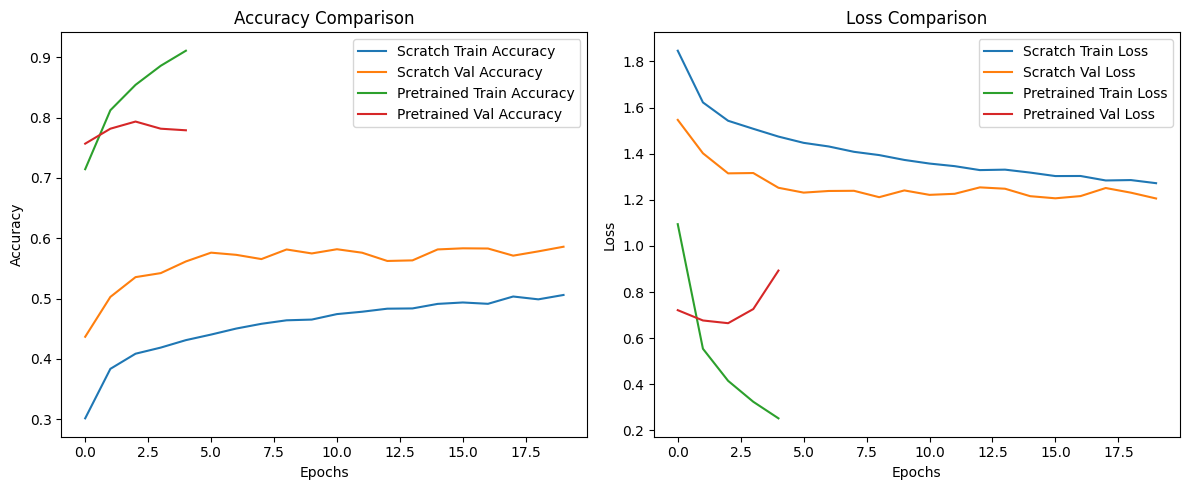

In [ ]:
# Importing necessary libraries
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

# Load the CIFAR-10 dataset
num_classes = 10
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Print the target image values
print("Target values (example):", y_train[:5])

# Normalize the data to the range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Split the training dataset into training and validation subsets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Print the sizes of the datasets
print(f"Training data shape: {X_train.shape}, Validation data shape: {X_val.shape}, Test data shape: {X_test.shape}")

# Standardizing the data
def standardize_dataset(X):
    image_means = []
    image_stds = []

    for image in X:
        image_means.append(np.mean(image))
        image_stds.append(np.std(image))

    dataset_mean = np.mean(image_means)
    dataset_std = np.mean(image_stds)
    return dataset_mean, dataset_std

train_mean, train_std = standardize_dataset(X_train)
X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

# One-hot encoding for target values
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_val = tf.keras.utils.to_categorical(y_val, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

# Build the CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, ReLU

model = Sequential([
    Conv2D(128, (3, 3), padding='same', input_shape=(32, 32, 3)),
    ReLU(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.25),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
batch_size = 64
epochs = 20
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=batch_size, epochs=epochs)

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy (from scratch model): {test_accuracy:.2f}")

# Build a model using a pretrained Xception network
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Input, UpSampling2D

pretrained_model = Sequential([
    UpSampling2D(size=(7, 7), input_shape=(32, 32, 3)),
    Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Freeze the layers of Xception
for layer in pretrained_model.layers[1].layers:
    layer.trainable = False

# Compile the pretrained model
pretrained_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the pretrained model
pretrained_history = pretrained_model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=batch_size, epochs=5)

# Evaluate the pretrained model on the test dataset
test_loss_pretrained, test_accuracy_pretrained = pretrained_model.evaluate(X_test, y_test)
print(f"Test accuracy (pretrained model): {test_accuracy_pretrained:.2f}")

# Plot comparison of training/validation accuracies and losses
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Scratch Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Scratch Val Accuracy')
plt.plot(pretrained_history.history['accuracy'], label='Pretrained Train Accuracy')
plt.plot(pretrained_history.history['val_accuracy'], label='Pretrained Val Accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Scratch Train Loss')
plt.plot(history.history['val_loss'], label='Scratch Val Loss')
plt.plot(pretrained_history.history['loss'], label='Pretrained Train Loss')
plt.plot(pretrained_history.history['val_loss'], label='Pretrained Val Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
